# 02. PCA Reduction dan Reconstruction Error

In [1]:
import random
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torchvision import datasets, transforms

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

In [2]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def get_project_root():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == "notebooks":
        return cwd.parent
    return cwd

PROJECT_ROOT = get_project_root()
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FEATURES_DIR = RESULTS_DIR / "features"

for path in [DATA_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR, FEATURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST


In [3]:
CONFIG = {
    "random_seed": 42,
    "input_dim": 784,
    "latent_dim": 32,
    "visualization_subset": 2000,
    "pca_train_subset": 10000,
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(CONFIG["random_seed"])

In [4]:
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=transform)
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print("Train size:", len(train_dataset))
print("Test size :", len(test_dataset))

Train size: 60000
Test size : 10000


In [5]:
def fixed_indices(dataset_length, subset_size, seed=42):
    subset_size = min(subset_size, dataset_length)
    rng = np.random.RandomState(seed)
    return rng.choice(dataset_length, size=subset_size, replace=False)

def dataset_to_numpy(dataset, indices):
    X, y = [], []
    for idx in indices:
        image, label = dataset[idx]
        X.append(image.view(-1).numpy())
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

pca_train_indices = fixed_indices(len(train_dataset), CONFIG["pca_train_subset"], CONFIG["random_seed"])
visualization_indices = fixed_indices(len(test_dataset), CONFIG["visualization_subset"], CONFIG["random_seed"])

X_train_pca, y_train_pca = dataset_to_numpy(train_dataset, pca_train_indices)
X_test_vis, y_test_vis = dataset_to_numpy(test_dataset, visualization_indices)
print("X_train_pca:", X_train_pca.shape)
print("X_test_vis :", X_test_vis.shape)

X_train_pca: (10000, 784)
X_test_vis : (2000, 784)


In [6]:
start_time = time.time()
pca = PCA(n_components=CONFIG["latent_dim"], random_state=CONFIG["random_seed"])
X_train_pca_features = pca.fit_transform(X_train_pca)
X_test_pca_features = pca.transform(X_test_vis)
pca_time = time.time() - start_time
explained_variance = float(np.sum(pca.explained_variance_ratio_))

print("PCA selesai.")
print("Shape PCA train features:", X_train_pca_features.shape)
print("Shape PCA test features :", X_test_pca_features.shape)
print("Explained variance total:", explained_variance)
print("Waktu PCA               :", pca_time, "detik")

PCA selesai.
Shape PCA train features: (10000, 32)
Shape PCA test features : (2000, 32)
Explained variance total: 0.826647937297821
Waktu PCA               : 0.16457819938659668 detik


In [7]:
X_test_pca_reconstructed = pca.inverse_transform(X_test_pca_features)
pca_reconstruction_mse = mean_squared_error(X_test_vis, X_test_pca_reconstructed)
print("PCA Reconstruction MSE:", pca_reconstruction_mse)

PCA Reconstruction MSE: 0.015454547479748726


In [8]:
np.save(FEATURES_DIR / "raw_features.npy", X_test_vis)
np.save(FEATURES_DIR / "labels.npy", y_test_vis)
np.save(FEATURES_DIR / "pca_features.npy", X_test_pca_features)
np.save(FEATURES_DIR / "pca_reconstructed.npy", X_test_pca_reconstructed)
with open(MODELS_DIR / "pca_model.pkl", "wb") as f:
    pickle.dump(pca, f)

pca_metrics = pd.DataFrame([{
    "method": "PCA",
    "input_dim": CONFIG["input_dim"],
    "latent_dim": CONFIG["latent_dim"],
    "train_size": len(X_train_pca),
    "test_size": len(X_test_vis),
    "explained_variance_ratio": explained_variance,
    "reconstruction_mse": pca_reconstruction_mse,
    "processing_time_seconds": pca_time
}])
pca_metrics_path = RESULTS_DIR / "pca_results.csv"
pca_metrics.to_csv(pca_metrics_path, index=False)
display(pca_metrics)
print("PCA metrics disimpan ke:", pca_metrics_path)

,method,input_dim,latent_dim,train_size,test_size,explained_variance_ratio,reconstruction_mse,processing_time_seconds
0,PCA,784,32,10000,2000,0.826648,0.015455,0.164578


PCA metrics disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\pca_results.csv


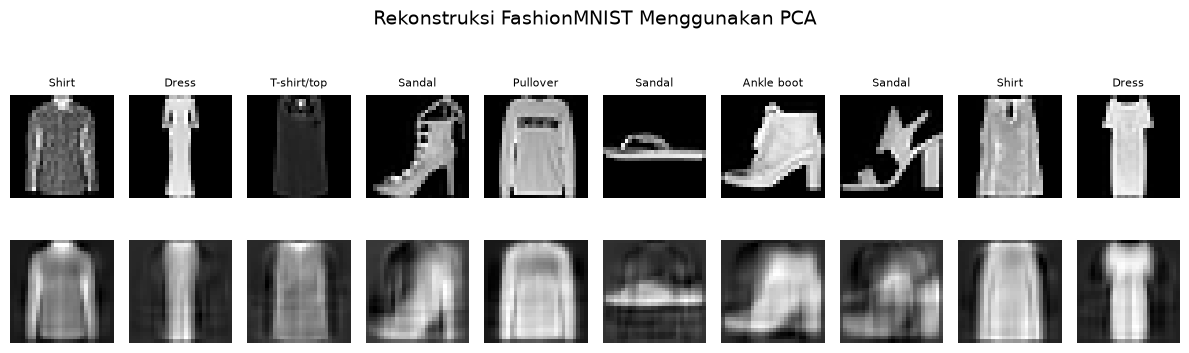

Gambar rekonstruksi disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\figures\pca_reconstruction.png


In [9]:
def show_reconstruction(original, reconstructed, labels, class_names, title, output_file, n=10):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap="gray")
        plt.title(class_names[labels[i]], fontsize=8)
        plt.axis("off")
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    output_path = FIGURES_DIR / output_file
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Gambar rekonstruksi disimpan ke:", output_path)

show_reconstruction(X_test_vis, X_test_pca_reconstructed, y_test_vis, class_names, "Rekonstruksi FashionMNIST Menggunakan PCA", "pca_reconstruction.png")